In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import os
# os.chdir('/content/drive/MyDrive/Project2/')

In [3]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
import tensorflow as tf
tf.__version__

'2.15.0'

In [6]:
import keras
keras.__version__

'2.15.0'

In [7]:
import cv2
import math
import time
import shutil
import random
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt

In [8]:
import keras_cv
import tensorflow_datasets as tfds
import tensorflow_addons as tfa

tfds.disable_progress_bar()
tf.keras.utils.set_random_seed(42)

Using TensorFlow backend


In [9]:
import logging
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [10]:
keras.saving.get_custom_objects().clear()
tf.keras.backend.clear_session() ## to clear other sessions in the environment
# tf.config.optimizer.set_jit(True) ## enabling XLA
# policy = tf.keras.mixed_precision.Policy('mixed_float16')
# tf.keras.mixed_precision.set_global_policy(policy)

In [11]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [12]:
!nvidia-smi

Sun Aug 24 23:13:19 2025       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.183.01             Driver Version: 535.183.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Quadro RTX 4000                Off | 00000000:73:00.0 Off |                  N/A |
| 37%   55C    P8               8W / 125W |      3MiB /  8192MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

# Variables

In [13]:
end = '_HAM10000_classification_PBA'
destination='results/ham10000/'

In [14]:
tempfolder="temp_HAM10000_PBA"
isExist = os.path.exists(tempfolder)
if not isExist:
    os.makedirs(tempfolder)

data_root='datasets/ham10000/'
output_path="./"+tempfolder+"/"

train_dir=data_root+"train/"
test_dir=data_root+"test/"

In [15]:
num_classes = len(os.listdir(train_dir))
num_train_images = len(glob(train_dir + '/*/*'))
num_test_images = len(glob(test_dir + '/*/*'))

print("num_classes : ", num_classes)
print("num_train_images : ", num_train_images)
print("num_test_images : ", num_test_images)

num_classes :  7
num_train_images :  6784
num_test_images :  1693


In [16]:
EPOCHS=20
IMG_SIZE=224
BATCH_SIZE=32
LEARNING_RATE=0.0001
dropout_rate=0.3
BUFFER_SIZE=num_train_images
AUTOTUNE = tf.data.AUTOTUNE

In [17]:
classes=sorted(os.listdir(train_dir))
print(classes)

['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [18]:
def parse_image(filename, label):
    image = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image, channels=3, dct_method="INTEGER_ACCURATE")
    # image = tf.image.decode_png(image, channels=3)
    # image = tf.image.decode_bmp(image, channels=3)
    image = tf.image.resize(image, (IMG_SIZE,IMG_SIZE), method="area")

    return image, label

In [19]:
file_names_train = glob(train_dir + '*/*')
random.shuffle(file_names_train)
lbls_train = [classes.index(name.split('/')[-2]) for name in file_names_train]
lbls_train_onehot = tf.one_hot(lbls_train, num_classes)
train_ds = tf.data.Dataset.from_tensor_slices((file_names_train, lbls_train_onehot))
train_ds = train_ds.map(parse_image, num_parallel_calls=AUTOTUNE)

In [20]:
from __future__ import annotations
import tensorflow as tf
from typing import List, Tuple, Optional, Any
import math

AUTOTUNE = tf.data.AUTOTUNE

# -----------------------------
# Stateless RNG helper
# -----------------------------
def _stateless_uniform(seed: tf.Tensor, shape, minval=0.0, maxval=1.0, dtype=tf.float32):
    """seed: int32[2] tensor"""
    return tf.random.stateless_uniform(shape, seed=seed, minval=minval, maxval=maxval, dtype=dtype)

# -----------------------------
# Augmentation ops (pure-TF)
# All ops accept (image, magnitude, seed) and return image.
# image is [H,W,C] (single image). For batch usage, augment_dataset should call per-image map.
# -----------------------------
def op_flip_lr(image, magnitude, seed):
    return tf.image.flip_left_right(image)

def op_flip_ud(image, magnitude, seed):
    return tf.image.flip_up_down(image)

def op_rotate_90k(image, magnitude, seed):
    # magnitude in [0,1] -> k in {0,1,2,3}
    k = tf.cast(tf.floor(magnitude * 4.0), tf.int32)
    return tf.image.rot90(image, k)

def op_brightness(image, magnitude, seed):
    # magnitude in [0,1] -> delta in [-0.5,0.5]
    delta = (magnitude - 0.5) * 0.5
    return tf.image.adjust_brightness(image, delta)

def op_contrast(image, magnitude, seed):
    # magnitude in [0,1] -> factor in [0.5,1.5]
    factor = 0.5 + magnitude
    return tf.image.adjust_contrast(image, factor)

def op_saturation(image, magnitude, seed):
    # magnitude in [0,1] -> factor in [0.5,1.5]
    factor = 0.5 + magnitude
    return tf.image.adjust_saturation(image, factor)

def op_translate(image, magnitude, seed):
    """
    Translate image by dx,dy sampled from uniform([-m, m]) where m = 0.2 * min(h,w) * magnitude.
    Uses tf.roll + mask to zero out wrapped regions. All done with TF ops and stateless RNG.
    """
    shape = tf.shape(image)
    h = tf.cast(shape[0], tf.int32)
    w = tf.cast(shape[1], tf.int32)
    c = shape[2]

    max_shift = tf.cast(tf.cast(tf.minimum(h, w), tf.float32) * 0.2 * magnitude, tf.int32)
    max_shift = tf.maximum(0, max_shift)

    # sample dx, dy scalars with stateless seed
    rnd = _stateless_uniform(seed, [2], minval=-1.0, maxval=1.0)
    dx = tf.cast(tf.round(rnd[0] * tf.cast(max_shift, tf.float32)), tf.int32)
    dy = tf.cast(tf.round(rnd[1] * tf.cast(max_shift, tf.float32)), tf.int32)

    rolled = tf.roll(image, shift=[dx, dy], axis=[0, 1])

    # build mask of ones and zero out wrapped regions
    # start with ones
    mask = tf.ones([h, w, c], dtype=image.dtype)

    # rows wrapped due to dx (vertical shift)
    abs_dx = tf.abs(dx)
    if_dx_pos = tf.greater(dx, 0)
    # zero top abs_dx rows if dx>0 else zero bottom abs_dx rows if dx<0
    mask = tf.cond(
        if_dx_pos,
        lambda: tf.concat([tf.zeros([abs_dx, w, c], dtype=image.dtype), mask[abs_dx:, ...]], axis=0),
        lambda: tf.cond(
            tf.equal(dx, 0),
            lambda: mask,
            lambda: tf.concat([mask[:h-abs_dx, ...], tf.zeros([abs_dx, w, c], dtype=image.dtype)], axis=0)
        )
    )

    # columns wrapped due to dy (horizontal shift)
    abs_dy = tf.abs(dy)
    if_dy_pos = tf.greater(dy, 0)
    mask = tf.cond(
        if_dy_pos,
        lambda: tf.concat([tf.zeros([h, abs_dy, c], dtype=image.dtype), mask[:, abs_dy:, :]], axis=1),
        lambda: tf.cond(
            tf.equal(dy, 0),
            lambda: mask,
            lambda: tf.concat([mask[:, :w-abs_dy, :], tf.zeros([h, abs_dy, c], dtype=image.dtype)], axis=1)
        )
    )

    return rolled * mask

def op_cutout(image, magnitude, seed):
    """
    Vectorized single-image cutout (used per-image inside graph).
    Ensures cutout_size >= 1. Uses broadcasted mask logic (but here for one image).
    """
    shape = tf.shape(image)
    h = tf.cast(shape[0], tf.int32)
    w = tf.cast(shape[1], tf.int32)
    c = shape[2]

    # compute cutout size (max 0.5 * min(h,w) * magnitude), ensure >=1
    max_size = tf.cast(tf.minimum(h, w), tf.float32) * 0.5
    cutout_size = tf.cast(tf.round(magnitude * max_size), tf.int32)
    cutout_size = tf.maximum(1, cutout_size)
    half = cutout_size // 2

    # sample center with stateless seed
    cy = tf.cast(tf.floor(_stateless_uniform(seed, [], 0.0, tf.cast(h, tf.float32))), tf.int32)
    cx = tf.cast(tf.floor(_stateless_uniform(tf.stack([seed[0], seed[1] ^ 0x9E3779B9]), [], 0.0, tf.cast(w, tf.float32))), tf.int32)

    # compute mask using ranges (vectorized)
    y_grid = tf.range(h)  # [H]
    x_grid = tf.range(w)  # [W]
    y0 = tf.cast(cy, tf.int32)
    x0 = tf.cast(cx, tf.int32)

    # boolean masks
    y_mask = (y_grid >= (y0 - half)) & (y_grid < (y0 + half))  # [H]
    x_mask = (x_grid >= (x0 - half)) & (x_grid < (x0 + half))  # [W]

    mask2d = ~(tf.expand_dims(y_mask, 1) & tf.expand_dims(x_mask, 0))  # [H,W]
    mask4d = tf.cast(tf.expand_dims(mask2d, -1), image.dtype)  # [H,W,1]
    return image * mask4d

# Registry list and dict (list is for tf.switch_case)
_OP_FUNCS_LIST = [
    op_flip_lr,
    op_flip_ud,
    op_rotate_90k,
    op_brightness,
    op_contrast,
    op_saturation,
    op_translate,
    op_cutout,
]
_OP_REGISTRY = {name: fn for name, fn in zip(
    ['flip_lr','flip_ud','rot90k','brightness','contrast','saturation','translate','cutout'],
    _OP_FUNCS_LIST
)}

# -----------------------------
# Policy containers (Python-side) and serialization
# -----------------------------
class PBAPolicy:
    """Simple container. ops: List[(op_name, prob, mag)]"""
    def __init__(self, ops: List[Tuple[str, float, float]]):
        self.ops = ops
    def __repr__(self):
        return f"PBAPolicy({self.ops})"

class PBAController:
    def __init__(self, pop_size=8, n_ops=3, op_names:Optional[List[str]]=None):
        self.pop_size = pop_size
        self.n_ops = n_ops
        self.op_names = op_names or list(_OP_REGISTRY.keys())
        self.policies: List[PBAPolicy] = []
        self.scores = [0.0] * pop_size

    def random_policy(self, seed: Optional[int]=None) -> PBAPolicy:
        import random
        if seed is not None:
            random.seed(seed)
        ops = []
        for _ in range(self.n_ops):
            op = random.choice(self.op_names)
            prob = random.random()
            mag = random.random()
            ops.append((op, prob, mag))
        return PBAPolicy(ops)

    def initialize_population(self, seed:Optional[int]=None):
        self.policies = [self.random_policy(seed=(seed+i) if seed else None) for i in range(self.pop_size)]
        self.scores = [0.0]*self.pop_size

    def report(self, idx:int, score:float):
        self.scores[idx] = float(score)

    def step(self, exploit_frac=0.2, mutate_prob=0.3):
        k = max(1, int(math.ceil(self.pop_size * exploit_frac)))
        ranking = sorted(range(self.pop_size), key=lambda i:self.scores[i], reverse=True)
        topk = ranking[:k]
        bottomk = ranking[-k:]
        for i, bidx in enumerate(bottomk):
            donor = self.policies[topk[i % k]]
            child = self._mutate_policy(donor, mutate_prob)
            self.policies[bidx] = child
            self.scores[bidx] = 0.0

    def _mutate_policy(self, policy:PBAPolicy, mutate_prob:float) -> PBAPolicy:
        import random
        new_ops = []
        for op_name, prob, mag in policy.ops:
            if random.random() < mutate_prob:
                op_name = random.choice(self.op_names)
            if random.random() < mutate_prob:
                prob = min(1.0, max(0.0, prob + random.uniform(-0.2,0.2)))
            if random.random() < mutate_prob:
                mag = min(1.0, max(0.0, mag + random.uniform(-0.2,0.2)))
            new_ops.append((op_name, prob, mag))
        return PBAPolicy(new_ops)

# Global holder for convenience (optional)
_CURRENT_POLICY: Optional[PBAPolicy] = None
def set_current_policy(policy:PBAPolicy):
    global _CURRENT_POLICY
    _CURRENT_POLICY = policy
def get_current_policy() -> Optional[PBAPolicy]:
    return _CURRENT_POLICY

# Serialize policy => tensor [n_ops, 3] where col0=op_idx (int), col1=prob (float), col2=mag (float)
def serialize_policy(policy: PBAPolicy, op_names: List[str]) -> tf.Tensor:
    name2idx = {n:i for i,n in enumerate(op_names)}
    rows = []
    for (op_name, prob, mag) in policy.ops:
        idx = name2idx.get(op_name, 0)
        rows.append([float(idx), float(prob), float(mag)])
    return tf.convert_to_tensor(rows, dtype=tf.float32)  # shape [n_ops,3]

# -----------------------------
# Pure-TF policy application (no py_function)
# -----------------------------
@tf.function
def apply_policy_tf(image: tf.Tensor, policy_tensor: tf.Tensor, base_seed: tf.Tensor):
    """
    image: [H,W,C] tensor
    policy_tensor: [n_ops,3] float32 (op_idx, prob, mag)
    base_seed: int32[2]
    """
    # ensure image dtype float32
    img = tf.cast(image, tf.float32)
    n_ops = tf.shape(policy_tensor)[0]

    i0 = tf.constant(0, tf.int32)
    # while loop state: (i, img)
    def cond(i, _img):
        return tf.less(i, n_ops)

    def body(i, _img):
        row = policy_tensor[i]   # [3]
        op_idx_f = row[0]
        prob = tf.cast(row[1], tf.float32)
        mag = tf.cast(row[2], tf.float32)
        op_idx = tf.cast(op_idx_f, tf.int32)

        # per-op seed derived from base_seed and i (stateless)
        seed_i = tf.stack([base_seed[0], base_seed[1] + i], axis=0)

        # sample a uniform to decide apply
        r = _stateless_uniform(seed_i, [], 0.0, 1.0)
        apply = tf.less(r, prob)

        # Branching function using tf.switch_case on op_idx
        def do_op():
            # branch_fns produce the transformed image for each op index
            def mk_branch(fn):
                return lambda: fn(_img, mag, seed_i)
            branches = [mk_branch(fn) for fn in _OP_FUNCS_LIST]
            # if op_idx is out-of-range, default to identity
            default = lambda: _img
            return tf.switch_case(op_idx, branch_fns=branches, default=default)

        new_img = tf.cond(apply, do_op, lambda: _img)
        return tf.add(i, 1), new_img

    _, out_img = tf.while_loop(cond, body, (i0, img), parallel_iterations=1)
    return out_img

# -----------------------------
# Public: augment_dataset
# - map augment BEFORE batching for best performance
# - returns a dataset that maps (image,label) -> (aug_image, label)
# -----------------------------
def augment_dataset(dataset: tf.data.Dataset, controller: Optional[PBAController]=None, policy_idx: int=0):
    """
    dataset: yields (image, label) where image is [H,W,C] (unbatched).
    controller: if provided, policies come from it (Python). We serialize the selected policy once.
    """
    if controller is not None:
        policy = controller.policies[policy_idx]
        policy_tensor = serialize_policy(policy, controller.op_names)
    else:
        policy = get_current_policy()
        if policy is None:
            raise ValueError("No current policy set")
        # use default op ordering from registry
        policy_tensor = serialize_policy(policy, list(_OP_REGISTRY.keys()))

    # map function (pure TF)
    def _map(image, label):
        # create a random base_seed (int32[2]) per example using stateless RNG with random seeds drawn from global RNG.
        # We use tf.random.uniform to create different seeds for each example in the pipeline — that's fine for determinism within a run.
        base_seed = tf.random.uniform([2], maxval=2**31-1, dtype=tf.int32)
        img = apply_policy_tf(image, policy_tensor, base_seed)
        # keep original dtype/shape signatures
        img = tf.cast(img, image.dtype)
        img.set_shape(image.shape)
        return img, label

    return dataset.map(_map, num_parallel_calls=AUTOTUNE)


# -----------------------------
# use it
# -----------------------------

controller = PBAController(pop_size=4, n_ops=3)
controller.initialize_population(seed=42)

set_current_policy(controller.policies[0])
aug_train_ds = augment_dataset(train_ds, controller, policy_idx=0)
aug_train_ds = aug_train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

for a,b in aug_train_ds.take(2):
    print(a.shape, b.shape)

(32, 224, 224, 3) (32, 7)
(32, 224, 224, 3) (32, 7)


In [21]:
file_names_test=glob(test_dir + '*/*')
lbls_test=[classes.index(name.split('/')[-2]) for name in file_names_test]
lbls_test_onehot = tf.one_hot(lbls_test, num_classes)
test_ds=tf.data.Dataset.from_tensor_slices((file_names_test, lbls_test_onehot))
test_ds=test_ds.map(parse_image, num_parallel_calls=AUTOTUNE)
test_ds=test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

In [22]:
tr_lb=np.array(lbls_train)
tr_lb_unique=np.unique(tr_lb)
print((np.unique(tr_lb, return_counts=True)))

(array([0, 1, 2, 3, 4, 5, 6]), array([ 177,  293,  675,   56,  684, 4828,   71]))


In [23]:
from sklearn.utils import compute_class_weight
#formula: n_samples / (n_classes * np.bincount(y))
classWeight=compute_class_weight(class_weight="balanced",classes=tr_lb_unique,y=tr_lb)
classWeight=np.round(classWeight,4)
classWeight_dict = dict(zip(tr_lb_unique, classWeight))
print("classWeight : ",classWeight_dict)

classWeight :  {0: 5.4754, 1: 3.3077, 2: 1.4358, 3: 17.3061, 4: 1.4169, 5: 0.2007, 6: 13.6499}


# Prepare Model

In [24]:
@keras.saving.register_keras_serializable('SpatialAttention')
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, kernel_size=3, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.kernel_size = kernel_size
        self.conv = tf.keras.layers.Conv2D(1, kernel_size, padding='same', activation='sigmoid')

    def call(self, inputs):
        avg_out = tf.keras.backend.mean(inputs, axis=-1, keepdims=True)
        max_out = tf.keras.backend.max(inputs, axis=-1, keepdims=True)
        concat = tf.keras.backend.concatenate([avg_out, max_out], axis=-1)
        attention_weights = self.conv(concat)
        return inputs * attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({"kernel_size": self.kernel_size})
        return config

In [25]:
base_model=tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE,IMG_SIZE,3))
base_model.trainable=True

x = SpatialAttention()(base_model.output)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(dropout_rate, name="dropout1")(x)
x = tf.keras.layers.Dense(512, activation="silu", name="pred1")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(dropout_rate, name="dropout2")(x)
x = tf.keras.layers.Dense(128, activation="silu", name="pred2")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(dropout_rate, name="dropout3")(x)
output = tf.keras.layers.Dense(num_classes, activation="softmax", name="pred3")(x)
model = tf.keras.Model(base_model.input, output, name="EfficientNetB0")

In [26]:
# till=model.layers.index(model.get_layer('block5a_expand_conv'))+1
# for layer in model.layers[:till]:
#     layer.trainable=False
# for layer in model.layers[till:]:
#     layer.trainable=True
    # if isinstance(layer, tf.keras.layers.BatchNormalization):
    #     layer.trainable = False

In [27]:
# i=1
# j=len(model.layers)
# for x in model.layers:
#     print(i, j, x.name, x.output.shape, x.trainable)
#     i=i+1
#     j=j-1

# Model Information

In [28]:
trainable_count = int(np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]))
non_trainable_count = int(np.sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights]))
total_count = trainable_count + non_trainable_count

print('Total params: {:,}'.format(total_count))
print('Trainable params: {:,}'.format(trainable_count))
print('Non-trainable params: {:,}'.format(non_trainable_count))

Total params: 4,779,709
Trainable params: 4,733,846
Non-trainable params: 45,863


In [29]:
from tensorflow.python.profiler.model_analyzer import profile
from tensorflow.python.profiler.option_builder import ProfileOptionBuilder

def get_flops(model):
  forward_pass = tf.function(model.call, input_signature=[tf.TensorSpec(shape=(1,) + model.input_shape[1:])])
  graph_info = profile(forward_pass.get_concrete_function().graph, options=ProfileOptionBuilder.float_operation())
  flops = graph_info.total_float_ops
  return flops

In [30]:
flops = get_flops(model)
macs = flops / 2


=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
scope: The nodes in the model graph are organized by their names, which is hierarchical like filesystem.
flops: Number of float operations. Note: Please read the implementation for the math behind it.

Profi

In [31]:
print(macs/10 ** 9)

0.394385947
flops)
  block4c_se_reduce/BiasAdd (20/20 flops)
  block4c_se_reduce/mul (20/20 flops)
  block4c_se_reduce/mul_1 (20/20 flops)
  block5a_se_reduce/BiasAdd (20/20 flops)
  block5a_se_reduce/mul (20/20 flops)
  block5a_se_reduce/mul_1 (20/20 flops)
  block3b_se_reduce/BiasAdd (10/10 flops)
  block3b_se_reduce/mul (10/10 flops)
  block3b_se_reduce/mul_1 (10/10 flops)
  block4a_se_reduce/BiasAdd (10/10 flops)
  block4a_se_reduce/mul (10/10 flops)
  block4a_se_reduce/mul_1 (10/10 flops)
  block1a_se_reduce/BiasAdd (8/8 flops)
  block1a_se_reduce/mul (8/8 flops)
  block1a_se_reduce/mul_1 (8/8 flops)
  pred3/BiasAdd (7/7 flops)
  block2b_se_reduce/BiasAdd (6/6 flops)
  block2b_se_reduce/mul (6/6 flops)
  block2b_se_reduce/mul_1 (6/6 flops)
  block3a_se_reduce/BiasAdd (6/6 flops)
  block3a_se_reduce/mul (6/6 flops)
  block3a_se_reduce/mul_1 (6/6 flops)
  block2a_se_reduce/BiasAdd (4/4 flops)
  block2a_se_reduce/mul (4/4 flops)
  block2a_se_reduce/mul_1 (4/4 flops)
  normalization/M

In [32]:
print(flops/10 ** 9)

0.788771894


# Train Model

In [33]:
regularizer=tf.keras.regularizers.l2(0.00001)
for layer in model.layers:
    for attr in ['kernel_regularizer']:
        if hasattr(layer, attr):
            setattr(layer, attr, regularizer)

In [34]:
optimizer_fn = tf.keras.optimizers.AdamW(learning_rate=LEARNING_RATE, clipnorm=2.0)
metrics = [tf.keras.metrics.CategoricalAccuracy(name='accuracy')]
loss_fn = tf.keras.losses.CategoricalFocalCrossentropy(gamma=5, label_smoothing=0.05)
model.compile(optimizer = optimizer_fn, loss = loss_fn, metrics = metrics)

In [35]:
def warmup_gpu(model, input_shape, dtype=tf.float32, steps=10):
    dummy_input = tf.random.normal([1, *input_shape], dtype=dtype)

    for i in range(steps):
        _ = model(dummy_input, training=False)
    print(f"[Warmup] GPU warmed up with {steps} dummy passes.")

# Example usage:
warmup_gpu(model, input_shape=(224, 224, 3))

[Warmup] GPU warmed up with 10 dummy passes.


In [36]:
ModelCheckPoint=tf.keras.callbacks.ModelCheckpoint(
    filepath=output_path+'EfficientNetB0-{epoch:03d}-{val_accuracy:.4f}.weights.h5',
    monitor='val_accuracy', verbose=1, save_best_only=True, save_weights_only=True)

In [37]:
def convert(seconds):
    hour = seconds // 3600
    seconds %= 3600
    minutes = seconds // 60
    seconds %= 60
    return "%d:%02d:%02d" % (hour, minutes, seconds)

In [38]:
for gen in range(5):  # number of generations
    for i, policy in enumerate(controller.policies):
        set_current_policy(policy)
        aug_train_ds = augment_dataset(train_ds, controller, policy_idx=i)
        aug_train_ds = aug_train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

        # train a child model for a few epochs
        history = model.fit(aug_train_ds, validation_data=test_ds, epochs=2, verbose=0)

        val_acc = history.history["val_accuracy"][-1]
        controller.report(i, val_acc)

    # exploit & explore
    controller.step()

I0000 00:00:1756057434.896145  439736 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [39]:
%%time
t1=time.time()
history = model.fit(
    aug_train_ds,
    epochs=EPOCHS,
    class_weight=classWeight_dict,
    validation_data=test_ds,
    callbacks=[ModelCheckPoint]
)
t2=time.time()
time_taken = t2-t1
print("Time taken : ",convert(time_taken)," hh:mm:ss")

Epoch 1/20
212/212 [==============================] - ETA: 0s - loss: 0.0505 - accuracy: 0.8989
Epoch 1: val_accuracy improved from -inf to 0.83639, saving model to ./temp_HAM10000_PBA/EfficientNetB0-001-0.8364.weights.h5
212/212 [==============================] - 59s 223ms/step - loss: 0.0505 - accuracy: 0.8989 - val_loss: 0.0673 - val_accuracy: 0.8364
Epoch 2/20
212/212 [==============================] - ETA: 0s - loss: 0.0445 - accuracy: 0.9033
Epoch 2: val_accuracy improved from 0.83639 to 0.84288, saving model to ./temp_HAM10000_PBA/EfficientNetB0-002-0.8429.weights.h5
212/212 [==============================] - 48s 228ms/step - loss: 0.0445 - accuracy: 0.9033 - val_loss: 0.0628 - val_accuracy: 0.8429
Epoch 3/20
212/212 [==============================] - ETA: 0s - loss: 0.0403 - accuracy: 0.8992
Epoch 3: val_accuracy improved from 0.84288 to 0.84406, saving model to ./temp_HAM10000_PBA/EfficientNetB0-003-0.8441.weights.h5
212/212 [==============================] - 48s 225ms/step - 

In [40]:
for x in sorted(os.listdir(output_path))[:-3]:
    os.remove(output_path+x)

In [41]:
model.load_weights(output_path+sorted(os.listdir(output_path))[-1])

In [42]:
test_loss, test_accuracy_by_evaluate = model.evaluate(test_ds)

53/53 [==============================] - 3s 46ms/step - loss: 0.0509 - accuracy: 0.8771


In [43]:
test_accuracy_by_evaluate_rounded = round((test_accuracy_by_evaluate)*100, 2)

In [44]:
Hist = {'hist' : history.history}
df = pd.DataFrame.from_dict(Hist)
df.to_csv(output_path+'Hist.csv', index = True, header=True)

In [45]:
num_epoch = len(history.history['loss'])
executed_epoch_count = len(history.history['loss'])

In [46]:
savedfilename="epochs_{}".format(executed_epoch_count)+"_test_acc_{}".format(test_accuracy_by_evaluate_rounded)

In [47]:
name=output_path+"{}".format(savedfilename)+".keras"
model.save(name)

In [48]:
name_weights=output_path+"{}".format(savedfilename)+".weights.h5"
model.save_weights(name_weights)

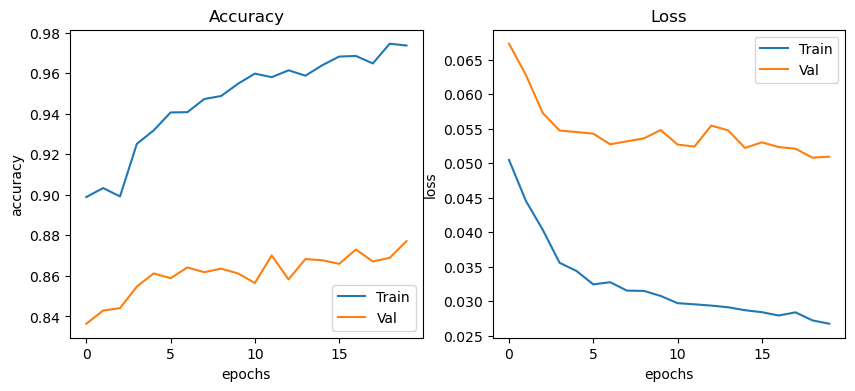

In [49]:
figpath=output_path+"{}".format(savedfilename)+".pdf"
fig = plt.figure(figsize=(10,4))
epochs_range = range(len(history.history['loss']))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Train')
plt.plot(epochs_range, history.history['val_accuracy'], label='Val')
plt.legend(loc='lower right')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Train')
plt.plot(epochs_range, history.history['val_loss'], label='Val')
plt.legend(loc='upper right')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()
fig.savefig(figpath, format='pdf', bbox_inches='tight')

# Predictions

In [50]:
# predictions=model.predict(test_dataset)
# y_pred = np.argmax(predictions, axis=1)
# y_true = np.concatenate([y for x, y in test_dataset], axis=0)
# y_prob = predictions

# same = 0
# total = len(y_true)

# for i in range(total):
#     if y_true[i] == y_pred[i]:
#         same=same+1

# test_acc = same/total*100
# res='{:.2f}'.format(test_acc)
# print(same)
# print(total)
# print(res)

In [51]:
%%time
predi=model.predict(test_ds)
y_p = np.argmax(predi, axis=1)
y_t = np.concatenate([y for x, y in test_ds], axis=0)
y_tt = np.argmax(y_t, axis=1)
y_pr = predi

same = 0
total = len(y_tt)

for i in range(total):
    if y_tt[i] == y_p[i]:
        same=same+1

test_acc = same/total*100
res='{:.2f}'.format(test_acc)
print(same)
print(total)
print(res)

53/53 [==============================] - 4s 41ms/step
1485
1693
87.71
CPU times: user 57.4 s, sys: 867 ms, total: 58.3 s
Wall time: 4.29 s


In [52]:
y_pred = y_p
y_true = y_tt
y_prob = y_pr

In [53]:
%%time
tm = []
correctly_classified = {"y_true":[], "y_pred":[], "y_prob":[], "filename":[], "inference_time":[]}
mis_classified = {"orig":[],"pred":[], "prob":[], "filename":[], "inference_time":[]}
for i in file_names_test:
    image=tf.keras.utils.load_img(i)
    input_arr=tf.keras.utils.img_to_array(image)
    img_resized=tf.image.resize(input_arr, size=(IMG_SIZE, IMG_SIZE))
    input_img=np.array([img_resized])
    start_time=time.time()
    predictions=model(input_img, training=False)
    end_time=time.time()
    t=1000*(end_time-start_time)
    tm.append(t)
    pr_fnl = np.argmax(predictions, axis=1)[0]
    lbl=classes.index(i.split('/')[-2])

    if lbl == pr_fnl:
        correctly_classified["y_true"].append(lbl)
        correctly_classified["y_pred"].append(pr_fnl)
        correctly_classified["y_prob"].append(predictions)
        correctly_classified["filename"].append(i)
        correctly_classified["inference_time"].append(t)
    else:
        mis_classified["orig"].append(lbl)
        mis_classified["pred"].append(pr_fnl)
        mis_classified["prob"].append(predictions)
        mis_classified["filename"].append(i)
        mis_classified["inference_time"].append(t)

print(len(correctly_classified["y_true"]))
print(len(y_t))
test_acc1 = len(correctly_classified["y_true"])/len(y_t)*100
print('{:.2f}'.format(test_acc1))

1418
1693
83.76
CPU times: user 3min 55s, sys: 784 ms, total: 3min 55s
Wall time: 3min 55s


In [54]:
# print(f"Average (ms) : {np.mean(tm)}")
# print(f"Std dev (ms) : {np.std(tm)}")
# print(f"Min     (ms) : {np.min(tm)}")
# print(f"Max     (ms) : {np.max(tm)}")

In [55]:
df11 = pd.DataFrame.from_dict(correctly_classified)
df11.to_csv(output_path+'correctly_classified.csv', index = True, header=True)

df22 = pd.DataFrame.from_dict(mis_classified)
df22.to_csv(output_path+'mis_classified.csv', index = True, header=True)

In [56]:
# y_pred1=correctly_classified["y_pred"]
# y_true1=correctly_classified["y_true"]
# y_prob1=correctly_classified["y_prob"]

# y_pred2=mis_classified["pred"]
# y_true2=mis_classified["orig"]
# y_prob2=mis_classified["prob"]

# y_pred=y_pred1+y_pred2
# y_true=y_true1+y_true2
# y_prob=y_prob1+y_prob2

In [57]:
y_test = tf.keras.utils.to_categorical(y_true)

In [58]:
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_true, y_pred)
print('Confusion Matrix\n')
print(confusion)

Confusion Matrix

[[  36    4    2    0    1    1    0]
 [   5   57    2    2    0    6    1]
 [   6    4  126    1    6   24    1]
 [   1    1    0   10    0    1    0]
 [   2    2   18    0  103   42    4]
 [   2    6   21    1   33 1139    5]
 [   0    1    0    0    1    1   14]]


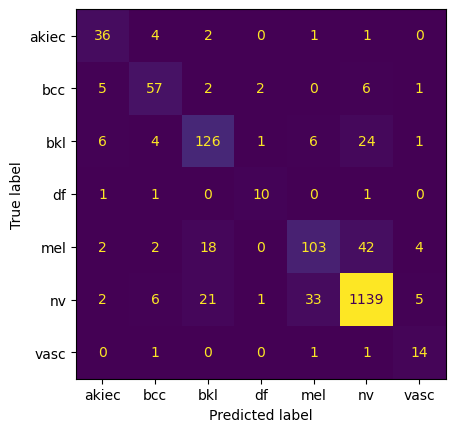

In [59]:
fig_path=output_path+"confusion_matrix.pdf"
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion, display_labels=classes).plot(colorbar=False)
fig=cm_display.figure_
fig.savefig(fig_path, format='pdf', bbox_inches='tight')

In [60]:
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_true, y_pred, normalize='all')
print('Confusion Matrix\n')
print(confusion)

Confusion Matrix

[[2.12640284e-02 2.36266982e-03 1.18133491e-03 0.00000000e+00
  5.90667454e-04 5.90667454e-04 0.00000000e+00]
 [2.95333727e-03 3.36680449e-02 1.18133491e-03 1.18133491e-03
  0.00000000e+00 3.54400473e-03 5.90667454e-04]
 [3.54400473e-03 2.36266982e-03 7.44240992e-02 5.90667454e-04
  3.54400473e-03 1.41760189e-02 5.90667454e-04]
 [5.90667454e-04 5.90667454e-04 0.00000000e+00 5.90667454e-03
  0.00000000e+00 5.90667454e-04 0.00000000e+00]
 [1.18133491e-03 1.18133491e-03 1.06320142e-02 0.00000000e+00
  6.08387478e-02 2.48080331e-02 2.36266982e-03]
 [1.18133491e-03 3.54400473e-03 1.24040165e-02 5.90667454e-04
  1.94920260e-02 6.72770230e-01 2.95333727e-03]
 [0.00000000e+00 5.90667454e-04 0.00000000e+00 0.00000000e+00
  5.90667454e-04 5.90667454e-04 8.26934436e-03]]


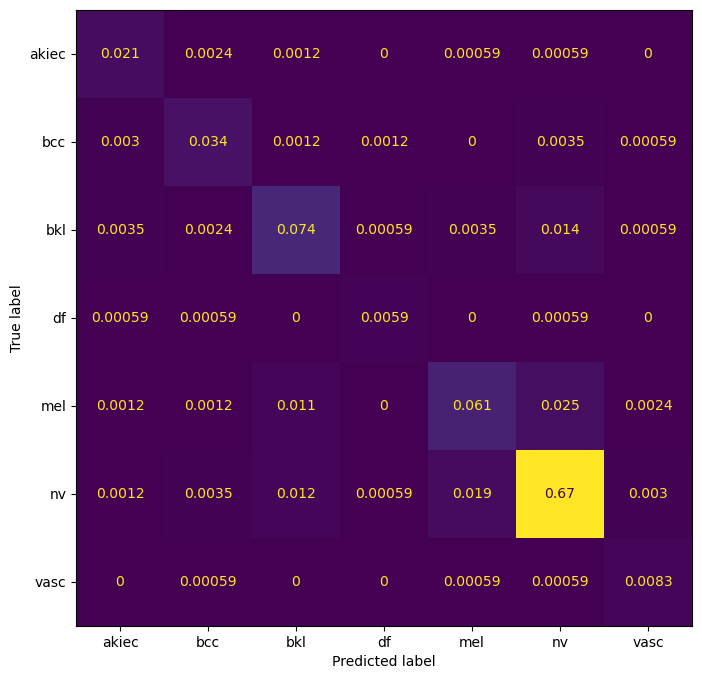

In [61]:
fig_path=output_path+"confusion_matrix1.pdf"
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion, display_labels=classes).plot(colorbar=False)
fig=cm_display.figure_
fig.set_figwidth(8)
fig.set_figheight(8)
fig.savefig(fig_path, format='pdf', bbox_inches='tight')

In [62]:
y_prob = np.array(y_prob)
y_prob_new = y_prob.reshape(y_pr.shape)

In [63]:
from sklearn.metrics import roc_auc_score
targetnames=classes
fpr = {}
tpr = {}
roc_auc = {}
for i in range(num_classes):
    r = roc_auc_score(y_test[:, i], y_prob_new[:, i])
    print("The ROC AUC score of "+targetnames[i]+" is: "+str(r))

The ROC AUC score of akiec is: 0.9714565301284526
The ROC AUC score of bcc is: 0.9626500930153897
The ROC AUC score of bkl is: 0.9598165495706479
The ROC AUC score of df is: 0.9552655677655677
The ROC AUC score of mel is: 0.9293481184345006
The ROC AUC score of nv is: 0.9516691044353753
The ROC AUC score of vasc is: 0.9473536431278955


In [64]:
from sklearn.metrics import roc_curve, auc
fpr = {}
tpr = {}
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_prob_new[:, i], drop_intermediate=False)
    roc_auc[i] = auc(fpr[i], tpr[i])

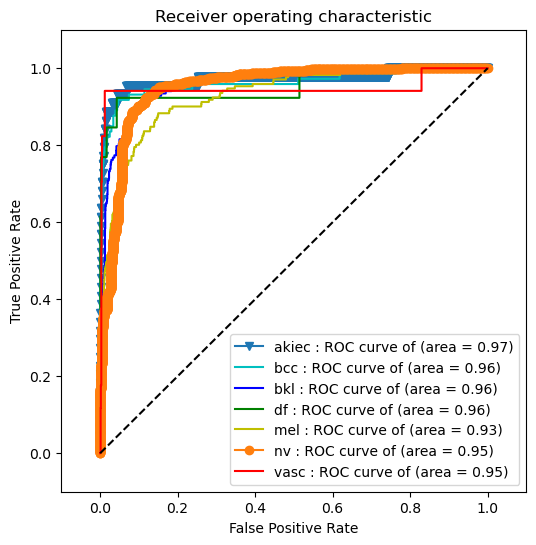

In [65]:
fig_path_roc=output_path+"roc_auc_curve.pdf"
fig = plt.figure(figsize=(6,6))
l0="{}".format(targetnames[0])+" : ROC curve of (area = {}".format(round(roc_auc[0],2))+")"
l1="{}".format(targetnames[1])+" : ROC curve of (area = {}".format(round(roc_auc[1],2))+")"
l2="{}".format(targetnames[2])+" : ROC curve of (area = {}".format(round(roc_auc[2],2))+")"
l3="{}".format(targetnames[3])+" : ROC curve of (area = {}".format(round(roc_auc[3],2))+")"
l4="{}".format(targetnames[4])+" : ROC curve of (area = {}".format(round(roc_auc[4],2))+")"
l5="{}".format(targetnames[5])+" : ROC curve of (area = {}".format(round(roc_auc[5],2))+")"
l6="{}".format(targetnames[6])+" : ROC curve of (area = {}".format(round(roc_auc[6],2))+")"
# l7="{}".format(targetnames[7])+" : ROC curve of (area = {}".format(round(roc_auc[7],2))+")"
# l8="{}".format(targetnames[8])+" : ROC curve of (area = {}".format(round(roc_auc[8],2))+")"
plt.plot(fpr[0], tpr[0],'v-',label=l0)
plt.plot(fpr[1], tpr[1],'c' ,label=l1)
plt.plot(fpr[2], tpr[2],'b' ,label=l2)
plt.plot(fpr[3], tpr[3],'g' ,label=l3)
plt.plot(fpr[4], tpr[4],'y' ,label=l4)
plt.plot(fpr[5], tpr[5],'o-',label=l5)
plt.plot(fpr[6], tpr[6],'r' ,label=l6)
# plt.plot(fpr[7], tpr[7],'o' ,label=l7)
# plt.plot(fpr[8], tpr[8],'c' ,label=l8)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()
fig.savefig(fig_path_roc, format='pdf', bbox_inches='tight')

In [66]:
from sklearn.metrics import accuracy_score
accuracy_score = accuracy_score(y_true, y_pred)
print('Accuracy: {}'.format(accuracy_score))

Accuracy: 0.8771411695215594


In [67]:
from sklearn.metrics import classification_report
classification_report = classification_report(y_true, y_pred,
    target_names=targetnames, zero_division=0)
print('Classification Report : \n')
print(classification_report)

Classification Report : 

              precision    recall  f1-score   support

       akiec       0.69      0.82      0.75        44
         bcc       0.76      0.78      0.77        73
         bkl       0.75      0.75      0.75       168
          df       0.71      0.77      0.74        13
         mel       0.72      0.60      0.65       171
          nv       0.94      0.94      0.94      1207
        vasc       0.56      0.82      0.67        17

    accuracy                           0.88      1693
   macro avg       0.73      0.78      0.75      1693
weighted avg       0.88      0.88      0.88      1693



In [68]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [69]:
micro_precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
weighted_precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Micro Precision: {micro_precision}")
print(f"Macro Precision: {macro_precision}")
print(f"Weighted Precision: {weighted_precision}")

Micro Precision: 0.8771411695215594
Macro Precision: 0.7322362960534387
Weighted Precision: 0.8769915211531586


In [70]:
micro_recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
weighted_recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Micro Recall: {micro_recall}")
print(f"Macro Recall: {macro_recall}")
print(f"Weighted Recall: {weighted_recall}")

Micro Recall: 0.8771411695215594
Macro Recall: 0.7839664385861498
Weighted Recall: 0.8771411695215594


In [71]:
micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Micro F1: {micro_f1}")
print(f"Macro F1: {macro_f1}")
print(f"Weighted F1: {weighted_f1}")

Micro F1: 0.8771411695215594
Macro F1: 0.7529077015589164
Weighted F1: 0.8761689956503059


In [72]:
from sklearn.metrics import roc_auc_score
micro_roc_auc_ovr = roc_auc_score(y_test, y_prob_new, multi_class="ovr",average="micro")
macro_roc_auc_ovr = roc_auc_score(y_test, y_prob_new, multi_class="ovr",average="macro")
weighted_roc_auc_ovr = roc_auc_score(y_true, y_prob_new, multi_class='ovr',average='weighted')

print(f"Micro-averaged One-vs-Rest ROC AUC score: {micro_roc_auc_ovr}")
print(f"Macro-averaged One-vs-Rest ROC AUC score: {macro_roc_auc_ovr}")
print(f"Weighted One-vs-Rest ROC AUC score: {weighted_roc_auc_ovr}")

Micro-averaged One-vs-Rest ROC AUC score: 0.9801690874263427
Macro-averaged One-vs-Rest ROC AUC score: 0.9539370866396898
Weighted One-vs-Rest ROC AUC score: 0.9511951128550316


In [73]:
from sklearn.metrics import balanced_accuracy_score
balanced_accuracy_score = balanced_accuracy_score(y_true, y_pred)
print('balanced_accuracy_score : ', balanced_accuracy_score)

balanced_accuracy_score :  0.7839664385861498


In [74]:
from sklearn.metrics import jaccard_score
jaccard_score = jaccard_score(y_true, y_pred, average='weighted')
print('jaccard_score : ', jaccard_score)

jaccard_score :  0.7938810583242478


In [75]:
specificity = []
cm = np.array(confusion_matrix(y_true, y_pred))
for i in range(cm.shape[0]):
    tn = np.sum(cm) - np.sum(cm[i, :]) - np.sum(cm[:, i]) + cm[i, i]
    fp = np.sum(cm[:, i]) - cm[i, i]
    specificity_i = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificity_i = np.round(specificity_i, 6)
    specificity.append(specificity_i)

print(f'Specificity for each class: {specificity}')
spec_unweighted=np.round(np.average(specificity), 6)
spec_weighted=np.round(np.average(specificity, weights=list(classWeight_dict.values())), 6)
print(spec_unweighted)
print(spec_weighted)

Specificity for each class: [0.990297, 0.988889, 0.971803, 0.997619, 0.973062, 0.845679, 0.993437]
0.965827
0.992281


In [76]:
from sklearn.metrics import multilabel_confusion_matrix
multilabel_confusion_matrix = multilabel_confusion_matrix(y_true, y_pred)
print('multilabel_confusion_matrix : \n', multilabel_confusion_matrix)

multilabel_confusion_matrix : 
 [[[1633   16]
  [   8   36]]

 [[1602   18]
  [  16   57]]

 [[1482   43]
  [  42  126]]

 [[1676    4]
  [   3   10]]

 [[1481   41]
  [  68  103]]

 [[ 411   75]
  [  68 1139]]

 [[1665   11]
  [   3   14]]]


# Saving All Results

In [77]:
import pandas as pd
Labels={'File_Name':[],'True_Label':[],'Predicted_Label':[],'Prediction_Probability':[]}

for i in range(len(file_names_test)):
    Labels['File_Name'].append(file_names_test[i])
    Labels['True_Label'].append(y_true[i])
    Labels['Predicted_Label'].append(y_pred[i])
    Labels['Prediction_Probability'].append(y_prob_new[i])

df = pd.DataFrame.from_dict(Labels)
df.to_csv(output_path+'Labels.csv', index = False, header=True)

In [78]:
Class_Weights = {'classWeight' : classWeight}
df = pd.DataFrame.from_dict(Class_Weights)
df.to_csv(output_path+'Class_Weights.csv', index = True, header=True)

In [79]:
Hist = {'hist' : history.history}
df = pd.DataFrame.from_dict(Hist)
df.to_csv(output_path+'Hist.csv', index = True, header=True)

In [80]:
Hyperparameters = {
    'Number_of_Classes' : num_classes,
    'Number_of_Train_Images' : num_train_images,
    'Number_of_Test_Images' : num_test_images,
    'BATCH_SIZE' : BATCH_SIZE,
    'IMG_SIZE' : IMG_SIZE,
    'LEARNING_RATE' : LEARNING_RATE,
    'EPOCHS' : EPOCHS,
    'Number_of_Epoch_Actually_Executed' : len(history.history['loss']),
}
df = pd.DataFrame.from_records([Hyperparameters]).transpose()
df.to_csv(output_path+'Hyperparameters.csv', index = True, header=False)

In [81]:
Results_in_Program = {
    'Time_Taken_for_execution_(in_seconds)' : time_taken,
    'Test_Accuracy_by_Model_Evaluate_Method' : test_accuracy_by_evaluate,
    'Number_of_Correct_Predictions' : same,
    'Number_of_Total_Predictions' : total,
    'Test_Accuracy_by_Manual_Matching' : test_acc,
    'Test_Accuracy_Result_Adjusted' : res
}
df = pd.DataFrame.from_records([Results_in_Program]).transpose()
df.to_csv(output_path+'Results_in_Program.csv', index = True, header=False)

In [82]:
Results = {
    'accuracy_score' : accuracy_score,
    'balanced_accuracy_score' : balanced_accuracy_score,
    'jaccard_score' : jaccard_score,

    'micro_precision':micro_precision,
    'macro_precision':macro_precision,
    'weighted_precision':weighted_precision,

    'micro_recall':micro_recall,
    'macro_recall':macro_recall,
    'weighted_recall':weighted_recall,

    'micro_f1':micro_f1,
    'macro_f1':macro_f1,
    'weighted_f1':weighted_f1,

    'micro_roc_auc_ovr': micro_roc_auc_ovr,
    'macro_roc_auc_ovr': macro_roc_auc_ovr,
    'weighted_roc_auc_ovr':weighted_roc_auc_ovr,

    'multilabel_confusion_matrix' : multilabel_confusion_matrix,
}
df = pd.DataFrame.from_records([Results]).transpose()
df.to_csv(output_path+'Results.csv', index = True, header=False)

In [83]:
classification_report = {'classification_report' : classification_report}
df = pd.DataFrame.from_records([classification_report]).transpose()
df.to_csv(output_path+'classification_report.csv', index = True, header=False)

In [84]:
Model_Name = model.name
Input_Shape = model.input_shape
Top_Layer_Dropout_Rate = dropout_rate
Model_Loss = type(model.loss)
Model_Optimizer = type(model.optimizer)
Model_Metrics_Names = model.metrics_names
Model_Metrics = model.metrics
Model_Trainable_Parameters_Count = trainable_count
Model_Non_Trainable_Parameters_Count = non_trainable_count
Model_Total_Parameters_Count = total_count
Model_Output_Shape = model.output_shape

Model_Parameters = {
    'Model_Name' : Model_Name,
    'Input_Shape' : Input_Shape,
    'Top_Layer_Dropout_Rate' : Top_Layer_Dropout_Rate,
    'Model_Loss' : Model_Loss,
    'Model_Optimizer' : Model_Optimizer,
    'LEARNING_RATE' : LEARNING_RATE,
    'Model_Metrics_Names' : Model_Metrics_Names,
    'Model_Metrics' : Model_Metrics,
    'Model_Trainable_Parameters_Count' : Model_Trainable_Parameters_Count,
    'Model_Non_Trainable_Parameters_Count' : Model_Non_Trainable_Parameters_Count,
    'Model_Total_Parameters_Count' : Model_Total_Parameters_Count,
    'Model_Output_Shape' : Model_Output_Shape
}
df = pd.DataFrame.from_records([Model_Parameters]).transpose()
df.to_csv(output_path+'Model_Parameters.csv', index = True, header=False)

# GradCAM

In [85]:
for im, lb in test_ds.take(1):
    sample_test_img = im.numpy()
    sample_test_lbl = lb.numpy()

In [86]:
img_idx=np.random.randint(sample_test_img.shape[0])

In [87]:
sa_model = tf.keras.models.Model(model.inputs,model.get_layer('spatial_attention').output)
sa_maps = sa_model.predict(sample_test_img)

1/1 [==============================] - 2s 2s/step


In [88]:
sum_attnmap = np.sum(sa_maps[img_idx],2)
sum_attnmap.shape

(7, 7)

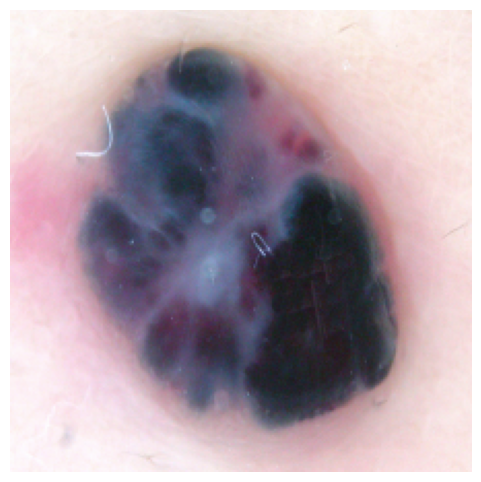

In [89]:
%matplotlib inline
fig_test_img=output_path+'fig_test_img.pdf'
fig=plt.figure(figsize=(6,6))
imgplot=plt.imshow(sample_test_img[img_idx].astype('uint8'))
plt.axis('off')
plt.show()
fig.savefig(fig_test_img, format='pdf', bbox_inches='tight')

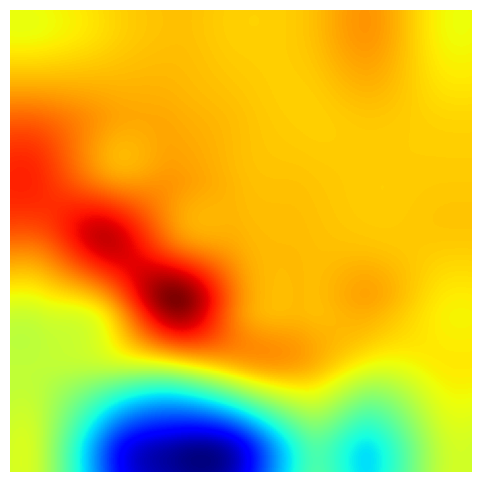

In [90]:
fig_heatmap=output_path+'fig_heatmap.pdf'
fig=plt.figure(figsize=(6,6))
#plt.imshow(sample_test_img[img_idx].astype('uint8'),alpha=1.0)
plt.imshow(cv2.resize(sum_attnmap,(IMG_SIZE,IMG_SIZE),interpolation=cv2.INTER_CUBIC),cmap='jet',alpha=1.0)
plt.axis('off')
plt.show()
fig.savefig(fig_heatmap, format='pdf', bbox_inches='tight')

# Model Plot

In [91]:
tf.keras.utils.plot_model(model, to_file=output_path+'model.pdf',
    show_shapes=True,
    show_dtype=True,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=True,
    dpi=1200,
    layer_range=None,
    show_layer_activations=True,
)

# Move temp to saved_models

In [92]:
from pytz import timezone
from datetime import datetime
cur_time=datetime.now(timezone("Asia/Kolkata")).strftime('%d-%m-%Y-%H-%M-%S')
name = cur_time + '_' + savedfilename + end
os.rename(tempfolder, name)
source = '{}'.format(name)+'/'
dest=shutil.move(source, destination)

In [93]:
print(dest)

results/ham10000/25-08-2025-00-05-19_epochs_20_test_acc_87.71_HAM10000_classification_PBA
